## Eficiencia por PIB
​**A Pergunta:** O dinheiro "compra" mais medalhas em qual dos dois eventos?

​A Comparação: Cruzar o PIB dos países com o quadro de medalhas de ambos os eventos.
​Hipótese: Equipamentos paralímpicos (cadeiras de rodas de titânio, próteses de fibra de carbono) são caríssimos. A correlação entre PIB e vitória é mais forte nas Paralimpíadas do que nas Olimpíadas


In [120]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [89]:
df_atletas = pd.read_csv('athlete_events_arrumado.csv', encoding='utf-8')
display(df_atletas.head())

df_idh = pd.read_csv('dadoss_idh_wikipedia.csv', encoding='utf-8')
display(df_idh.head())

df_pib = pd.read_csv('pib_mundial_2024_worldometers.csv', encoding='utf-8')
display(df_pib.head())

df_olimpiadas = pd.read_csv('medalhas_olimpiadas_wikipedia.csv', encoding='utf-8')
display(df_olimpiadas.head())

df_paraolimpiadas = pd.read_csv('medalhas_paralimpiadas_wikipedia.csv', encoding='utf-8')
display(df_paraolimpiadas.head())

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,8,"Cornelia ""Cor"" Aalten (-Strannood)",F,18.0,168.0,NaN,Netherlands,NED,1932 Summer,1932,Summer,Los Angeles,Athletics,Athletics Women's 100 metres,NaN


,Posição,Mudança desde 2015,País ou território,IDH,% crescimento anual (2010–2023)
0,1,(2),Islândia,972,"0,28%"
1,2,(1),Noruega,970,"0,25%"
2,2,NaN,Suíça,970,"0,24%"
3,4,(2),Dinamarca,962,"0,35%"
4,5,(1),Alemanha,959,"0,19%"


,#,País,PIB,PIB (Valor Total),Crescimento do PIB,PIB per Capita
0,1,Estados Unidos,"$29,3 trilhões",$29.298.025.000.000,"2,8%",$86.145
1,2,China,"$18,75 trilhões",$18.749.759.000.000,5%,$13.314
2,3,Alemanha,"$4,68 trilhões",$4.684.182.000.000,"−0,5%",$56.087
3,4,Japão,"$4,02 trilhões",$4.019.382.000.000,"0,1%",$32.443
4,5,Índia,"$3,91 trilhões",$3.909.892.000.000,"6,5%",$2.695


,No.,País,Jogos,Ouro,Prata,Bronze,Total
0,1,USA Estados Unidos,29,1101,880,781,2762
1,2,URS União Soviética,9,395,319,296,1010
2,3,CHN China,12,302,227,197,726
3,4,GBR Grã-Bretanha,30,300,338,344,982
4,5,FRA França,30,240,280,298,818


,País,№,Ouro,Prata,Bronze,Total
0,África do Sul (RSA),11,121,95,88,304
1,Alemanha (GER) [a],8,199,266,253,718
2,Alemanha Ocidental (FRG) [b],8,322,260,246,828
3,Alemanha Oriental (GDR) [c],1,0,3,1,4
4,Angola (ANG),6,4,3,1,8


In [90]:
df_pib.info()
display(list(df_pib.columns)) 
df_olimpiadas.info()
display(list(df_olimpiadas.columns))  
df_paraolimpiadas.info()
display(list(df_paraolimpiadas.columns))


<class 'pandas.DataFrame'>
RangeIndex: 218 entries, 0 to 217
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   #                   218 non-null    int64
 1   País                218 non-null    str  
 2   PIB                 218 non-null    str  
 3   PIB (Valor Total)   218 non-null    str  
 4   Crescimento do PIB  218 non-null    str  
 5   PIB per Capita      218 non-null    str  
dtypes: int64(1), str(5)
memory usage: 10.3 KB


['#',
 'País',
 'PIB',
 'PIB (Valor Total)',
 'Crescimento do PIB',
 'PIB per Capita']

<class 'pandas.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   No.     155 non-null    int64
 1   País    155 non-null    str  
 2   Jogos   155 non-null    int64
 3   Ouro    155 non-null    int64
 4   Prata   155 non-null    int64
 5   Bronze  155 non-null    int64
 6   Total   155 non-null    int64
dtypes: int64(6), str(1)
memory usage: 8.6 KB


['No.', 'País', 'Jogos', 'Ouro', 'Prata', 'Bronze', 'Total']

<class 'pandas.DataFrame'>
RangeIndex: 132 entries, 0 to 131
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   País    132 non-null    str  
 1   №       132 non-null    int64
 2   Ouro    132 non-null    int64
 3   Prata   132 non-null    int64
 4   Bronze  132 non-null    int64
 5   Total   132 non-null    int64
dtypes: int64(5), str(1)
memory usage: 6.3 KB


['País', '№', 'Ouro', 'Prata', 'Bronze', 'Total']

trata o texto do nome das olimpiadas pois estava diferente do que tem no pib, estava: USA Estados Unidos, após o tratamento fica uma coluna para o país que tem só o nome: Estados Unidos e outra coluna para a NOC que recebe a sigla (talvez use no futuro para comparar com a tabela de atletas em outras analises).

In [91]:
# 1. Extrair as 3 primeiras letras maiúsculas que estão no início do texto
# A expressão r'^([A-Z]{3})\s+(.*)' diz: 
# - Pega as 3 primeiras letras maiúsculas (^([A-Z]{3}))
# - Pula o espaço (\s+)
# - Pega todo o resto do texto ((.*))
df_para_limpo = df_olimpiadas['País'].str.extract(r'^([A-Z]{3})\s+(.*)')
# 2. Renomear as colunas geradas pelo extract
df_para_limpo.columns = ['NOC', 'País_Limpo']

# 3. Adicionar essas colunas de volta ao DataFrame original ou criar um novo
df_olimpiadas['NOC'] = df_para_limpo['NOC']
df_olimpiadas['País'] = df_para_limpo['País_Limpo']

# 4. Limpeza final (remover referências tipo [a] ou asteriscos que sobraram no nome)
df_olimpiadas['País'] = df_olimpiadas['País'].str.replace(r'\[.*\]|\*', '', regex=True).str.strip()

display(df_olimpiadas.head())

,No.,País,Jogos,Ouro,Prata,Bronze,Total,NOC
0,1,Estados Unidos,29,1101,880,781,2762,USA
1,2,União Soviética,9,395,319,296,1010,URS
2,3,China,12,302,227,197,726,CHN
3,4,Grã-Bretanha,30,300,338,344,982,GBR
4,5,França,30,240,280,298,818,FRA


Trata as paralimpiadas 

In [92]:
# Captura o que está entre ( )
df_paraolimpiadas['NOC'] = df_paraolimpiadas['País'].str.extract(r'\((.*?)\)')

# Remove tudo que começa com parênteses e limpa referências [a]
df_paraolimpiadas['País'] = df_paraolimpiadas['País'].str.replace(r'\s*\(.*', '', regex=True)
df_paraolimpiadas['País'] = df_paraolimpiadas['País'].str.replace(r'\[.*\]', '', regex=True).str.strip()


display(df_paraolimpiadas.head())

,País,№,Ouro,Prata,Bronze,Total,NOC
0,África do Sul,11,121,95,88,304,RSA
1,Alemanha,8,199,266,253,718,GER
2,Alemanha Ocidental,8,322,260,246,828,FRG
3,Alemanha Oriental,1,0,3,1,4,GDR
4,Angola,6,4,3,1,8,ANG


Junta as Tres alemanhas paralimpicas em uma só

In [93]:
# Aqui transformamos as variações no nome padrão que existe no seu PIB
alemanhas = ['Alemanha Ocidental', 'Alemanha Oriental']
df_paraolimpiadas['País'] = df_paraolimpiadas['País'].replace(alemanhas, 'Alemanha')

# 5. AGRUPAR E SOMAR (Agora elas viram uma só linha)
df_para_final = df_paraolimpiadas.groupby('País').agg({
    'Total': 'sum',
    'NOC': 'first' # Mantém o NOC da Alemanha atual (GER)
}).reset_index()
display(df_para_final.head())

,País,Total,NOC
0,Alemanha,1550,GER
1,Angola,8,ANG
2,Argentina,165,ARG
3,Argélia,85,ALG
4,Arábia Saudita,5,KSA


Cria o total de medalhas olimpicas e paralimpicas

In [99]:
# Criando o total de medalhas Olímpicas por país
df_olimpico_total = df_olimpiadas.groupby('País')['Total'].sum().reset_index()
df_olimpico_total = df_olimpico_total.sort_values(by='Total', ascending=False)
df_olimpico_total.columns = ['País', 'Total_Olimpico']

# Criando o total de medalhas Paralímpicas por país
df_paralimpico_total = df_paraolimpiadas.groupby('País')['Total'].sum().reset_index()
df_paralimpico_total = df_paralimpico_total.sort_values(by='Total', ascending=False)
df_paralimpico_total.columns = ['País', 'Total_Paralimpico']

In [100]:
display(df_olimpico_total.head())
display(df_paralimpico_total.head())

,País,Total_Olimpico
53,Estados Unidos,2762
143,União Soviética,1010
65,Grã-Bretanha,982
60,França,818
31,China,726


,País,Total_Paralimpico
115,Totais,22147
40,Estados Unidos,2283
48,Grã-Bretanha,1914
0,Alemanha,1550
22,China,1237


In [108]:
df_olimpico_total.columns = ['País', 'Total_Olimpico']
df_paralimpico_total.columns = ['País', 'Total_Paralimpico']

# 2. Unindo as medalhas (Olimpíadas + Paralimpíadas)
# Chamaremos de 'df_performance' porque ele guarda o resultado esportivo puro
df_performance = pd.merge(df_olimpico_total, df_paralimpico_total, on='País', how='outer')

# 3. Criando o DataFrame Mestre (Cruzamento com o PIB)
# Vamos chamar de 'df_analise_socioeconomica'
# Aqui usamos 'inner' para garantir que só fiquem países com dados completos
df_analise_socioeconomica = pd.merge(df_performance, df_pib, on='País', how='inner').sort_values(by='Total_Olimpico', ascending=False)
df_analise_socioeconomica.fillna(0, inplace=True)
display(df_analise_socioeconomica.head())

,País,Total_Olimpico,Total_Paralimpico,#,PIB,PIB (Valor Total),Crescimento do PIB,PIB per Capita
44,Estados Unidos,2762.0,2283.0,1,"$29,3 trilhões",$29.298.025.000.000,"2,8%",$86.145
50,França,818.0,1092.0,7,"$3,16 trilhões",$3.160.902.000.000,"1,1%",$46.187
25,China,726.0,1237.0,2,"$18,75 trilhões",$18.749.759.000.000,5%,$13.314
1,Alemanha,685.0,1550.0,3,"$4,68 trilhões",$4.684.182.000.000,"−0,5%",$56.087
69,Itália,657.0,665.0,8,"$2,37 trilhões",$2.372.059.000.000,"0,7%",$40.224


C:\Users\maria\AppData\Local\Temp\ipykernel_1836\176120725.py:7: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:steelblue'` for the same effect.

  sns.barplot(data=df_plot, x='País', y='Medalhas', hue='Tipo', color='steelblue')


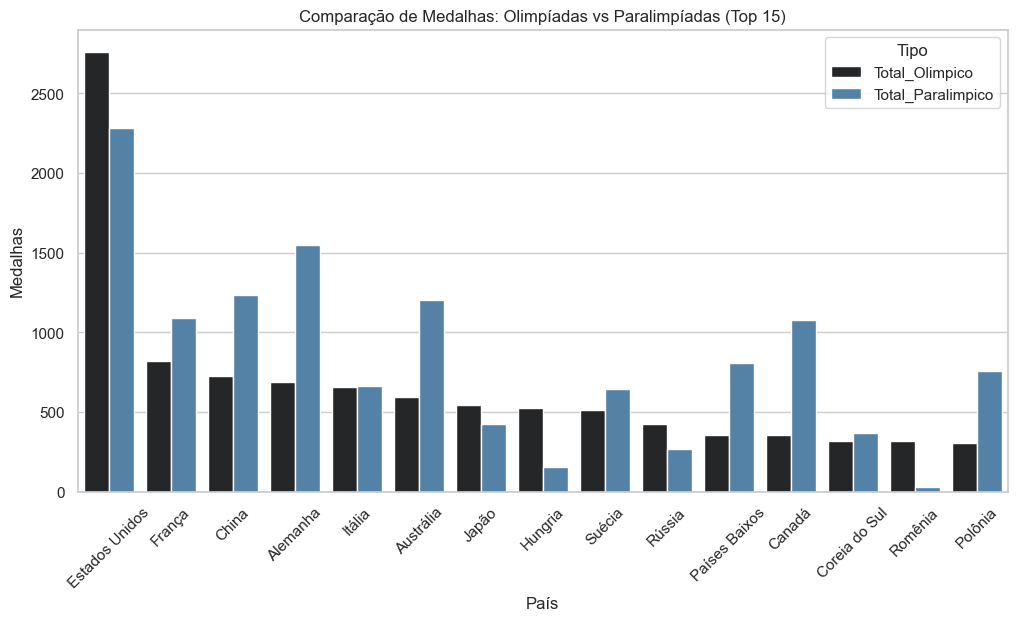

In [136]:
df_top = df_analise_socioeconomica.nlargest(15, 'Total_Olimpico')

df_plot = df_top.melt(id_vars='País', value_vars=['Total_Olimpico', 'Total_Paralimpico'], 
                      var_name='Tipo', value_name='Medalhas')

plt.figure(figsize=(12, 6))
sns.barplot(data=df_plot, x='País', y='Medalhas', hue='Tipo', color='steelblue')
plt.xticks(rotation=45)
plt.title('Comparação de Medalhas: Olimpíadas vs Paralimpíadas (Top 15)')
plt.show()

# Agora vamos analizar o total de medalha a cada 1 bilhao do pib

Primeiro para as paralimpiadas

Arrumar a coluna: 'PIB (Valor Total)' que tinha formato string pois tinha um '$' antes do valor do PIB, vamos transforma-la em um valor real usando o to_numeric do pandas

In [124]:
df_analise_socioeconomica['PIB_Numerico'] = df_analise_socioeconomica['PIB (Valor Total)'].str.replace(r'[\$\.]', '', regex=True)

df_analise_socioeconomica['PIB_Numerico'] = pd.to_numeric(df_analise_socioeconomica['PIB_Numerico'])

#Cria uma coluna chamada 'eficiencia_para' para a analise, esse coluna recebe o total de medalhas paralimpicas do df_analise_socioeconomica e divide pelo pib numerico que é o que pib que tratamos ateriormente dividido por 1e12 para transformar o valor em trilhões

In [ ]:
df_analise_socioeconomica['Eficiencia_Para'] = df_analise_socioeconomica['Total_Paralimpico'] / (df_analise_socioeconomica['PIB_Numerico'] / 1e12) 

#Aqui criamos o grafico que realiza o comparativo entre a eficiência dos países em relação ao PIB e as medalhas paralimpicas.

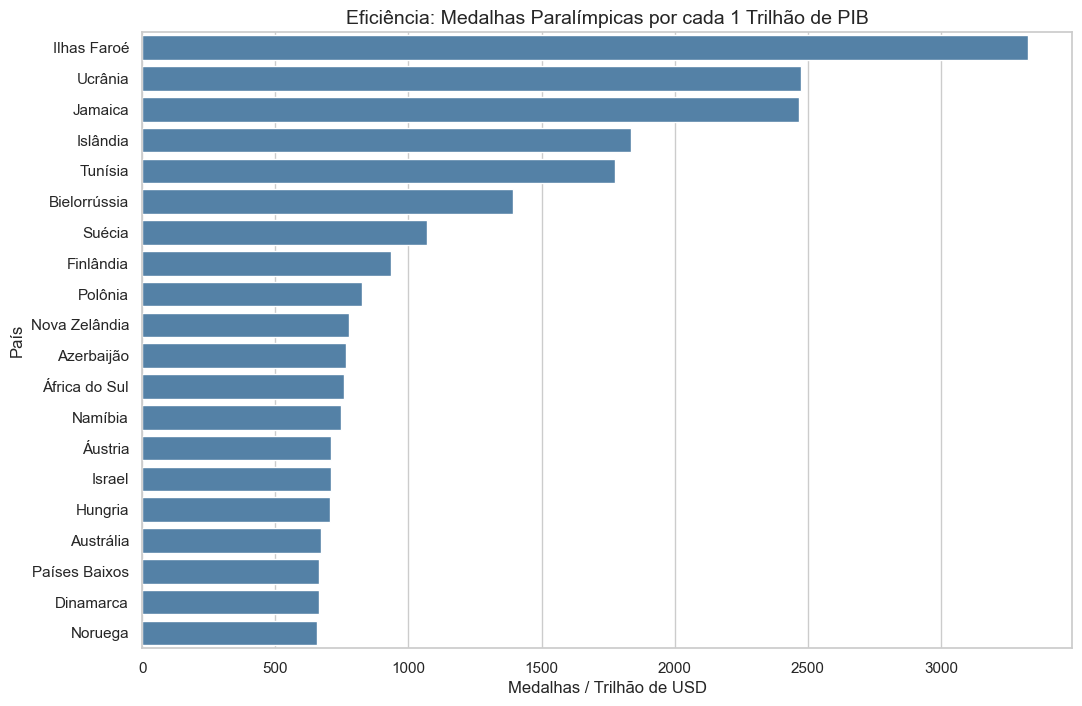

In [132]:
df_ranking = df_analise_socioeconomica.nlargest(20, 'Eficiencia_Para')

plt.figure(figsize=(12, 8))
sns.barplot(data=df_ranking, x='Eficiencia_Para', y='País', color='steelblue')

plt.title('Eficiência: Medalhas Paralímpicas por cada 1 Trilhão de PIB', fontsize=14)
plt.xlabel('Medalhas / Trilhão de USD')
plt.ylabel('País')
plt.show()  
